# 推理服务架构：生产环境 LLM 的端到端系统设计

> **难度：** 高级 | **时间：** 约 40 分钟

在本系列中，我们逐步构建了高效 LLM 推理的核心技术 —— KV-cache（notebook 00）、FlashAttention（01）、continuous batching（02）、PagedAttention（03）、prefix caching（04）、量化（05）、投机解码（06）和引导生成（07）。每项技术解决一个瓶颈。在生产环境中，它们必须在一个 **服务系统** 内协同工作，该系统负责路由请求、调度 GPU 工作、管理内存并将 token 流式传输回用户。

本 notebook 作为系列总结，从 **架构** 角度出发，我们将：

1. 绘制现代 LLM 服务栈的端到端组件架构
2. 探索 **prefill / decode 解耦** —— 为什么以及如何将两个阶段分配到不同的 worker
3. 设计 **PD Connector**，在 prefill 和 decode worker 之间传输 KV-cache
4. 研究 **分布式 KV-cache 存储**，将所有组件连接在一起
5. 追踪完整的 **请求生命周期**，从客户端到流式响应
6. 对比实际的服务框架：vLLM、TGI 和 TensorRT-LLM

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.plantuml import render_plantuml
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

---
## 1. 端到端架构概览

生产环境的 LLM 服务系统远不止是一个循环运行的模型。它是一个分布式系统，各组件各司其职：

| 组件 | 职责 |
|------|------|
| **API 网关 / 路由器** | 接受 HTTP/gRPC 请求，认证、限流、路由到后端 |
| **调度器** | 决定运行哪些请求、何时抢占、如何组成 batch |
| **Prefill Worker** | 处理输入 prompt（计算密集型阶段） |
| **Decode Worker** | 自回归生成输出 token（内存密集型阶段） |
| **KV-Cache 存储** | 管理分布式块表、页分配、写时复制 |
| **PD Connector** | 将 KV-cache 从 prefill 传输到 decode worker |
| **流式代理** | 将 SSE/WebSocket 流多路复用回客户端 |

下面的组件图展示了这些部件如何连接。

In [2]:
render_plantuml("""
@startuml
skinparam componentStyle rectangle
skinparam backgroundColor white
skinparam defaultFontSize 13

actor "Client" as client

package "API Layer" {
  [API Gateway\n/ Router / LB] as router
}

package "Orchestration" {
  [Scheduler] as sched
  [Batch Manager] as batcher
}

package "Compute Pool" {
  [Prefill Worker 0\n(GPU, compute-bound)] as pw0
  [Prefill Worker 1\n(GPU, compute-bound)] as pw1
  [Decode Worker 0\n(GPU, memory-bound)] as dw0
  [Decode Worker 1\n(GPU, memory-bound)] as dw1
  [Decode Worker 2\n(GPU, memory-bound)] as dw2
}

package "Memory Layer" {
  [KV-Cache Store\n(Distributed Block Manager)] as kvstore
  [PD Connector\n(RDMA / NVLink / TCP)] as pdconn
}

package "Response" {
  [Streaming Proxy\n(SSE / WebSocket)] as stream
}

client --> router : HTTP/gRPC
router --> sched : enqueue request
sched --> batcher : form batch
batcher --> pw0 : prefill batch
batcher --> pw1 : prefill batch
pw0 --> pdconn : KV-cache blocks
pw1 --> pdconn : KV-cache blocks
pdconn --> dw0 : transfer KV
pdconn --> dw1 : transfer KV
pdconn --> dw2 : transfer KV
dw0 --> kvstore : alloc / free pages
dw1 --> kvstore : alloc / free pages
dw2 --> kvstore : alloc / free pages
pw0 --> kvstore : populate pages
pw1 --> kvstore : populate pages
dw0 --> stream : tokens
dw1 --> stream : tokens
dw2 --> stream : tokens
stream --> client : SSE stream

@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam componentStyle rectangle
skinparam backgroundColor white
skinparam defaultFontSize 13

actor "Client" as client

package "API Layer" {
  [API Gateway
/ Router / LB] as router
}

package "Orchestration" {
  [Scheduler] as sched
  [Batch Manager] as batcher
}

package "Compute Pool" {
  [Prefill Worker 0
(GPU, compute-bound)] as pw0
  [Prefill Worker 1
(GPU, compute-bound)] as pw1
  [Decode Worker 0
(GPU, memory-bound)] as dw0
  [Decode Worker 1
(GPU, memory-bound)] as dw1
  [Decode Worker 2
(GPU, memory-bound)] as dw2
}

package "Memory Layer" {
  [KV-Cache Store
(Distributed Block Manager)] as kvstore
  [PD Connector
(RDMA / NVLink / TCP)] as pdconn
}

package "Response" {
  [Streaming Proxy
(SSE / WebSocket)] as stream
}

client --> router : HTTP/gRPC
router --> sched : enqueue request
sched --> batcher : form batch
batcher --> pw0 : prefill batch
batcher --> pw1 : prefill batch
pw0 --> pdconn : KV-cache blocks
pw1 --> pdconn : KV-cache blocks
pdconn --> dw0 : transfer KV
pdconn --> dw1 : transfer KV
pdconn --> dw2 : transfer KV
dw0 --> kvstore : alloc / free pages
dw1 --> kvstore : alloc / free pages
dw2 --> kvstore : alloc / free pages
pw0 --> kvstore : populate pages
pw1 --> kvstore : populate pages
dw0 --> stream : tokens
dw1 --> stream : tokens
dw2 --> stream : tokens
stream --> client : SSE stream

@enduml
```

该图展示了现代服务系统的关键架构选择：**prefill 和 decode 是独立的 worker 池**，通过 KV-cache 传输层连接。这称为 **prefill/decode 解耦（disaggregation）**，是本 notebook 的核心思想。

---
## 2. Prefill / Decode 解耦

回忆 notebook 00（KV-Cache）中提到，LLM 推理有两个计算特征截然不同的阶段：

| 属性 | Prefill | Decode |
|------|---------|--------|
| **处理的 token 数** | 所有 prompt token 一次性处理（数百到数千） | 每步一个新 token |
| **瓶颈** | 计算密集（高算术强度） | 内存密集（低算术强度） |
| **GPU 利用率** | 高（大型矩阵乘法） | 低（大部分时间用于加载权重） |
| **延迟目标** | 首 token 延迟（TTFT） | token 间延迟（ITL） |
| **最佳 batch size** | 小 batch（每个请求本身已经并行） | 大 batch（分摊权重加载开销） |

### 为什么要解耦？

如果 prefill 和 decode 共享同一个 GPU，它们会 **相互干扰**：

- 长时间的 prefill 会阻塞 decode 步骤，导致所有正在进行的请求的 token 生成 **停顿**
- Decode 需要大 batch 来分摊内存带宽开销；prefill 需要小 batch 来最小化 TTFT
- 最优 GPU 类型不同：prefill 受益于高 FLOPS（A100/H100），decode 受益于高内存带宽（通常是相同的 GPU，但 batch 配置不同）

通过拆分为独立的 worker 池，每个池可以 **独立扩缩容和优化**。

In [3]:
info_box(
    "Prefill/decode disaggregation was popularized by systems like Splitwise (2024) "
    "and DistServe (2024). The core insight: mixing compute-bound and memory-bound "
    "workloads on the same GPU leads to suboptimal utilization for both. Separating "
    "them allows each pool to be tuned independently — different batch sizes, different "
    "parallelism strategies, even different GPU types.",
    title="Historical context"
)

In [4]:
# Quantify the utilization gap between prefill and decode

# A100 specs
a100_tflops = 312  # BF16 TFLOPS
a100_membw_tbs = 2.0  # TB/s HBM bandwidth
roofline_intensity = a100_tflops / a100_membw_tbs  # FLOPs/byte at roofline knee

d_model = 4096
n_layers = 32
model_params = 7e9
bytes_per_param = 2  # FP16
model_bytes = model_params * bytes_per_param

# Arithmetic intensity = FLOPs / bytes_loaded
# For linear layers: 2 * params * batch_tokens FLOPs, model_bytes loaded

scenarios = [
    ("Prefill (512 tokens)",  512),
    ("Prefill (2048 tokens)", 2048),
    ("Decode (batch=1)",      1),
    ("Decode (batch=8)",      8),
    ("Decode (batch=64)",     64),
    ("Decode (batch=256)",    256),
]

print(f"A100 roofline knee: {roofline_intensity:.0f} FLOPs/byte")
print(f"{'Scenario':<25} | {'Tokens':>7} | {'Intensity':>12} | {'Bound':>14} | {'Utilization':>11}")
print("-" * 80)

for label, tokens in scenarios:
    flops = 2 * model_params * tokens
    mem_loaded = model_bytes  # must load all weights
    intensity = flops / mem_loaded
    
    if intensity >= roofline_intensity:
        # Compute-bound: utilization = 1.0 (idealized)
        bound = "Compute-bound"
        utilization = min(1.0, intensity / roofline_intensity)  # capped at 1
        utilization = 1.0  # saturating compute
    else:
        # Memory-bound: utilization = intensity / roofline
        bound = "Memory-bound"
        utilization = intensity / roofline_intensity
    
    print(f"{label:<25} | {tokens:>7} | {intensity:>9.0f} F/B | {bound:>14} | {utilization:>10.1%}")

A100 roofline knee: 156 FLOPs/byte
Scenario                  |  Tokens |    Intensity |          Bound | Utilization
--------------------------------------------------------------------------------
Prefill (512 tokens)      |     512 |       512 F/B |  Compute-bound |     100.0%
Prefill (2048 tokens)     |    2048 |      2048 F/B |  Compute-bound |     100.0%
Decode (batch=1)          |       1 |         1 F/B |   Memory-bound |       0.6%
Decode (batch=8)          |       8 |         8 F/B |   Memory-bound |       5.1%
Decode (batch=64)         |      64 |        64 F/B |   Memory-bound |      41.0%
Decode (batch=256)        |     256 |       256 F/B |  Compute-bound |     100.0%


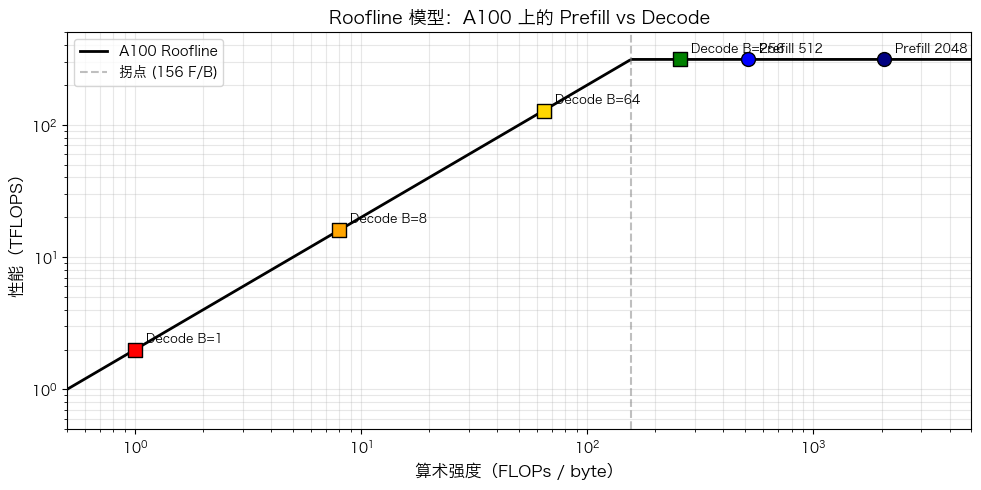

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Roofline model visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# A100 specs
peak_tflops = 312
peak_membw = 2.0  # TB/s
knee = peak_tflops / peak_membw  # 156

intensities = np.logspace(-1, 4, 500)
perf = np.minimum(intensities * peak_membw, peak_tflops)

ax.loglog(intensities, perf, 'k-', linewidth=2, label='A100 Roofline')
ax.axvline(knee, color='gray', linestyle='--', alpha=0.5, label=f'Knee ({knee:.0f} F/B)')

# Plot scenarios
points = [
    ('Decode B=1',   1,    'red',    's', 12),
    ('Decode B=8',   8,    'orange', 's', 12),
    ('Decode B=64',  64,   'gold',   's', 12),
    ('Decode B=256', 256,  'green',  's', 12),
    ('Prefill 512',  512,  'blue',   'o', 12),
    ('Prefill 2048', 2048, 'navy',   'o', 12),
]

for label, tokens, color, marker, size in points:
    ai = 2 * model_params * tokens / model_bytes  # = tokens (for FP16)
    achieved = min(ai * peak_membw, peak_tflops)
    ax.scatter(ai, achieved, c=color, marker=marker, s=100, zorder=5, edgecolors='black')
    ax.annotate(label, (ai, achieved), textcoords='offset points', xytext=(8, 5), fontsize=9)

ax.set_xlabel('Arithmetic Intensity (FLOPs / byte)', fontsize=12)
ax.set_ylabel('Performance (TFLOPS)', fontsize=12)
ax.set_title('Roofline Model: Prefill vs Decode on A100', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0.5, 5000)
ax.set_ylim(0.5, 500)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Roofline 图直观地说明了：**小 batch 的 decode 浪费了超过 99% 的 GPU 算力**。相比之下，prefill 可以轻松填满计算单元。解耦使我们能够：

- 以 **大 batch**（数百个请求）运行 decode，使其更接近 roofline 拐点
- 以 **小的、延迟优化的 batch** 运行 prefill，实现快速的首 token 延迟
- 根据流量模式 **独立扩缩** prefill 和 decode 池

### 实践中的扩缩比例

Prefill 和 decode worker 的比例取决于工作负载：

| 工作负载 | 输入/输出比 | Prefill:Decode 比例 |
|----------|-----------|--------------------|
| 聊天机器人（短 prompt，长回复） | 低 | 1:4 或 1:8 |
| 文本摘要（长文档，短输出） | 高 | 1:1 或 2:1 |
| 代码补全（中等上下文，短输出） | 中 | 1:2 |
| RAG（长上下文，中等输出） | 高 | 1:1 |

---
## 3. PD Connector 设计：在 Worker 之间传输 KV-Cache

解耦引入了一个新挑战：当 prefill worker 计算完 prompt 的 KV-cache 后，必须将该缓存 **传输** 到 decode worker。这是 **PD Connector**（Prefill-Decode 连接器）的工作。

单个请求的 KV-cache 可能很大。对于一个 7B 模型、2048 个 prompt token、FP16 精度：

$$\text{KV 大小} = 2 \times 32\text{ 层} \times 32\text{ 头} \times 128\text{ 维度} \times 2048\text{ token} \times 2\text{ 字节} = 1.07\text{ GB}$$

这个传输必须 **快速** —— 它位于 prefill 完成和第一个 decode token 之间的关键路径上。

In [6]:
# Calculate KV-cache transfer sizes and times for different interconnects

def kv_cache_size_gb(n_layers, n_kv_heads, head_dim, seq_len, dtype_bytes=2):
    """Size of KV-cache for one request in GB."""
    return 2 * n_layers * n_kv_heads * head_dim * seq_len * dtype_bytes / (1024**3)

# Model configs
configs = [
    ("LLaMA-7B (MHA)",   32, 32, 128),
    ("LLaMA-70B (GQA)",  80,  8, 128),
    ("Mixtral-8x7B",     32, 8,  128),
]

# Interconnect bandwidths (GB/s, unidirectional)
interconnects = [
    ("TCP (100 GbE)",     12.5),
    ("RDMA (200 Gb IB)",  25.0),
    ("RDMA (400 Gb IB)",  50.0),
    ("NVLink (A100)",    300.0),
    ("NVLink (H100)",    450.0),
    ("Shared HBM",     2000.0),
]

seq_len = 2048
print(f"KV-Cache transfer time for seq_len={seq_len} (single request)\n")
print(f"{'Model':<20} | {'KV Size':>8}", end="")
for name, _ in interconnects:
    print(f" | {name:>15}", end="")
print()
print("-" * 130)

for model_name, layers, kv_heads, hdim in configs:
    size_gb = kv_cache_size_gb(layers, kv_heads, hdim, seq_len)
    print(f"{model_name:<20} | {size_gb:>6.2f}GB", end="")
    for ic_name, bw_gbs in interconnects:
        time_ms = size_gb / bw_gbs * 1000
        print(f" | {time_ms:>12.1f} ms", end="")
    print()

KV-Cache transfer time for seq_len=2048 (single request)

Model                |  KV Size |   TCP (100 GbE) | RDMA (200 Gb IB) | RDMA (400 Gb IB) |   NVLink (A100) |   NVLink (H100) |      Shared HBM
----------------------------------------------------------------------------------------------------------------------------------
LLaMA-7B (MHA)       |   1.00GB |         80.0 ms |         40.0 ms |         20.0 ms |          3.3 ms |          2.2 ms |          0.5 ms
LLaMA-70B (GQA)      |   0.62GB |         50.0 ms |         25.0 ms |         12.5 ms |          2.1 ms |          1.4 ms |          0.3 ms
Mixtral-8x7B         |   0.25GB |         20.0 ms |         10.0 ms |          5.0 ms |          0.8 ms |          0.6 ms |          0.1 ms


In [7]:
# Sequence diagram: PD Connector handoff
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

participant "Scheduler" as S
participant "Prefill Worker" as PW
participant "PD Connector" as PDC
participant "KV-Cache Store" as KVS
participant "Decode Worker" as DW

S -> PW : dispatch(request, prompt_tokens)
activate PW

PW -> KVS : allocate_pages(num_blocks)
KVS --> PW : page_table, block_ids

PW -> PW : run prefill forward pass
note right of PW : Compute KV for all\nprompt tokens in parallel\n(compute-bound)

PW -> KVS : write KV blocks
PW -> PDC : notify_complete(request_id, page_table)
deactivate PW

PDC -> S : prefill_done(request_id, kv_metadata)
S -> DW : schedule_decode(request_id)
activate DW

DW -> PDC : fetch_kv(request_id)
PDC -> KVS : read KV blocks
note right of PDC : Transfer via RDMA / NVLink\n(overlap with other work)
KVS --> PDC : KV data
PDC --> DW : KV blocks + page_table

DW -> DW : append to local KV-cache
loop until EOS or max_tokens
  DW -> DW : decode one token
  DW --> S : stream token
end

DW -> KVS : free_pages(block_ids)
deactivate DW

@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

participant "Scheduler" as S
participant "Prefill Worker" as PW
participant "PD Connector" as PDC
participant "KV-Cache Store" as KVS
participant "Decode Worker" as DW

S -> PW : dispatch(request, prompt_tokens)
activate PW

PW -> KVS : allocate_pages(num_blocks)
KVS --> PW : page_table, block_ids

PW -> PW : run prefill forward pass
note right of PW : Compute KV for all
prompt tokens in parallel
(compute-bound)

PW -> KVS : write KV blocks
PW -> PDC : notify_complete(request_id, page_table)
deactivate PW

PDC -> S : prefill_done(request_id, kv_metadata)
S -> DW : schedule_decode(request_id)
activate DW

DW -> PDC : fetch_kv(request_id)
PDC -> KVS : read KV blocks
note right of PDC : Transfer via RDMA / NVLink
(overlap with other work)
KVS --> PDC : KV data
PDC --> DW : KV blocks + page_table

DW -> DW : append to local KV-cache
loop until EOS or max_tokens
  DW -> DW : decode one token
  DW --> S : stream token
end

DW -> KVS : free_pages(block_ids)
deactivate DW

@enduml
```

### 传输策略对比

传输机制的选择取决于部署拓扑：

In [8]:
comparison_table(
    headers=["Method", "Bandwidth", "Latency", "Topology", "Pros", "Cons"],
    rows=[
        ["TCP/IP", "~12 GB/s", "~100 us", "Cross-node",
         "Universal, cheap", "Slow for large KV; CPU overhead"],
        ["RDMA (InfiniBand)", "25-50 GB/s", "~1-2 us", "Cross-node",
         "Zero-copy, low latency", "Requires IB hardware"],
        ["NVLink", "300-900 GB/s", "<1 us", "Intra-node",
         "Highest bandwidth", "Only within same server"],
        ["Shared GPU memory", "~2 TB/s", "~ns", "Same GPU",
         "Zero transfer cost", "No disaggregation (collocated)"],
    ],
    title="KV-Cache Transfer Mechanisms"
)

方式,带宽,延迟,拓扑,优点,缺点
TCP/IP,~12 GB/s,~100 us,跨节点,通用、成本低,大 KV 传输慢；CPU 开销
RDMA (InfiniBand),25-50 GB/s,~1-2 us,跨节点,零拷贝、低延迟,需要 IB 硬件
NVLink,300-900 GB/s,<1 us,节点内,最高带宽,仅限同一服务器内
共享 GPU 内存,~2 TB/s,~ns,同一 GPU,零传输开销,无法解耦（共置模式）


### 优化：流水线传输

朴素的实现方式是等待整个 prefill 完成后再开始传输。更好的方法是 **逐层流水线** 传输：

1. 一旦第 $l$ 层的 prefill 完成，立即开始传输其 KV 块
2. 当第 $l$ 层的 KV 在传输途中时，第 $l+1$ 层仍在计算
3. 当 prefill 结束时，大部分 KV 块已经到达 decode worker

这可以将有效传输延迟从整个 KV-cache 大小降低到大约一层的大小。

In [9]:
# Pipelined vs non-pipelined transfer latency

n_layers = 32
kv_total_gb = kv_cache_size_gb(32, 32, 128, 2048)  # LLaMA-7B
kv_per_layer_gb = kv_total_gb / n_layers
rdma_bw = 50.0  # GB/s (400 Gb IB)

# Assume prefill takes 50ms for 2048 tokens on A100
prefill_time_ms = 50.0
prefill_per_layer_ms = prefill_time_ms / n_layers

# Non-pipelined: wait for all prefill, then transfer everything
transfer_all_ms = kv_total_gb / rdma_bw * 1000
non_pipelined_ms = prefill_time_ms + transfer_all_ms

# Pipelined: overlap transfer with computation
transfer_per_layer_ms = kv_per_layer_gb / rdma_bw * 1000
# The bottleneck is max(prefill_per_layer, transfer_per_layer)
pipeline_stage_ms = max(prefill_per_layer_ms, transfer_per_layer_ms)
# Total = prefill of first layer + pipeline stages + transfer of last layer
pipelined_ms = prefill_time_ms + transfer_per_layer_ms  # last layer's transfer

print(f"LLaMA-7B, seq_len=2048, 400 Gb/s InfiniBand")
print(f"KV-cache total: {kv_total_gb*1024:.0f} MB ({kv_per_layer_gb*1024:.1f} MB/layer)")
print(f"Prefill time: {prefill_time_ms:.0f} ms ({prefill_per_layer_ms:.1f} ms/layer)")
print(f"Transfer time (full): {transfer_all_ms:.1f} ms ({transfer_per_layer_ms:.2f} ms/layer)")
print()
print(f"Non-pipelined TTFT: {non_pipelined_ms:.1f} ms (prefill + full transfer)")
print(f"Pipelined TTFT:     {pipelined_ms:.1f} ms (prefill + last layer transfer)")
print(f"Savings:            {non_pipelined_ms - pipelined_ms:.1f} ms ({(1 - pipelined_ms/non_pipelined_ms)*100:.0f}% faster)")

LLaMA-7B, seq_len=2048, 400 Gb/s InfiniBand
KV-cache total: 1024 MB (32.0 MB/layer)
Prefill time: 50 ms (1.6 ms/layer)
Transfer time (full): 20.0 ms (0.62 ms/layer)

Non-pipelined TTFT: 70.0 ms (prefill + full transfer)
Pipelined TTFT:     50.6 ms (prefill + last layer transfer)
Savings:            19.4 ms (28% faster)


---
## 4. KV-Cache 存储架构

在解耦系统中，KV-cache 不再是简单的单 GPU tensor。它变成了一个 **分布式内存系统**，拥有自己的页表、块分配和一致性要求。这直接建立在 notebook 03 中的 PagedAttention 概念之上。

### 关键组件

| 组件 | 角色 |
|------|------|
| **Block Manager** | 分配和释放固定大小的 KV 块（类似操作系统的页分配器） |
| **页表** | 将 (request_id, layer, token_range) 映射到物理块位置 |
| **块池** | 预分配的 GPU 内存，划分为固定大小的块 |
| **引用计数** | 跟踪写时复制（prefix caching）的共享情况 |

### 分布式 Block Manager

在多 worker 场景下，block manager 必须跨 GPU 协调：

In [10]:
# Simulate a distributed block manager

class DistributedBlockManager:
    """Simplified distributed KV-cache block manager."""
    
    def __init__(self, n_workers, blocks_per_worker, block_size=16):
        self.n_workers = n_workers
        self.block_size = block_size  # tokens per block
        # Each worker has its own pool of free blocks
        self.free_blocks = {
            w: list(range(blocks_per_worker)) for w in range(n_workers)
        }
        # Page table: request_id -> {worker_id: [block_ids]}
        self.page_tables = {}
        # Reference counts for copy-on-write (prefix caching)
        self.ref_counts = {
            w: {b: 0 for b in range(blocks_per_worker)} for w in range(n_workers)
        }
    
    def allocate(self, request_id, worker_id, n_tokens):
        """Allocate blocks for a request on a specific worker."""
        n_blocks = (n_tokens + self.block_size - 1) // self.block_size
        if len(self.free_blocks[worker_id]) < n_blocks:
            return None  # OOM
        
        blocks = [self.free_blocks[worker_id].pop(0) for _ in range(n_blocks)]
        for b in blocks:
            self.ref_counts[worker_id][b] = 1
        
        if request_id not in self.page_tables:
            self.page_tables[request_id] = {}
        self.page_tables[request_id][worker_id] = blocks
        return blocks
    
    def share_prefix(self, new_request_id, source_request_id, worker_id, n_shared_tokens):
        """Copy-on-write: share prefix blocks between requests (prefix caching)."""
        n_shared_blocks = n_shared_tokens // self.block_size
        source_blocks = self.page_tables[source_request_id][worker_id][:n_shared_blocks]
        
        # Increment ref counts instead of copying
        for b in source_blocks:
            self.ref_counts[worker_id][b] += 1
        
        if new_request_id not in self.page_tables:
            self.page_tables[new_request_id] = {}
        self.page_tables[new_request_id][worker_id] = list(source_blocks)
        return source_blocks
    
    def free(self, request_id, worker_id):
        """Free blocks when request completes."""
        blocks = self.page_tables.get(request_id, {}).get(worker_id, [])
        freed = []
        for b in blocks:
            self.ref_counts[worker_id][b] -= 1
            if self.ref_counts[worker_id][b] == 0:
                self.free_blocks[worker_id].append(b)
                freed.append(b)
        if request_id in self.page_tables:
            self.page_tables[request_id].pop(worker_id, None)
        return freed
    
    def status(self):
        for w in range(self.n_workers):
            total = len(self.free_blocks[w]) + sum(
                1 for b, rc in self.ref_counts[w].items() if rc > 0
            )
            used = sum(1 for b, rc in self.ref_counts[w].items() if rc > 0)
            print(f"  Worker {w}: {used}/{total} blocks used, {len(self.free_blocks[w])} free")

In [11]:
# Demo: allocate, share (prefix caching), and free
bm = DistributedBlockManager(n_workers=3, blocks_per_worker=16, block_size=16)

print("=== Initial state ===")
bm.status()

# Request A: 200 tokens on decode worker 0
blocks_a = bm.allocate("req_A", worker_id=0, n_tokens=200)
print(f"\nAllocated req_A on worker 0: blocks {blocks_a} ({len(blocks_a)} blocks for 200 tokens)")

# Request B: 150 tokens on decode worker 1
blocks_b = bm.allocate("req_B", worker_id=1, n_tokens=150)
print(f"Allocated req_B on worker 1: blocks {blocks_b}")

# Request C shares a 128-token prefix with A (same system prompt) — copy-on-write
shared = bm.share_prefix("req_C", "req_A", worker_id=0, n_shared_tokens=128)
print(f"\nreq_C shares prefix with req_A (copy-on-write): blocks {shared}")
# Allocate remaining unique tokens for C
extra = bm.allocate("req_C_unique", worker_id=0, n_tokens=64)
print(f"req_C unique suffix: blocks {extra}")

# Check ref counts on shared blocks
print(f"\nRef counts for shared blocks on worker 0:")
for b in shared:
    print(f"  Block {b}: ref_count = {bm.ref_counts[0][b]}")

print("\n=== After allocations ===")
bm.status()

# Free request A — shared blocks stay (ref_count > 0)
freed = bm.free("req_A", worker_id=0)
print(f"\nFreed req_A: actually freed blocks {freed}")
print("(Shared prefix blocks retained for req_C)")

print("\n=== After freeing req_A ===")
bm.status()

=== 初始状态 ===
  Worker 0: 0/16 blocks used, 16 free
  Worker 1: 0/16 blocks used, 16 free
  Worker 2: 0/16 blocks used, 16 free

Allocated req_A on worker 0: blocks [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] (13 blocks for 200 tokens)
Allocated req_B on worker 1: blocks [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

req_C shares prefix with req_A (copy-on-write): blocks [0, 1, 2, 3, 4, 5, 6, 7]
req_C unique suffix: blocks None

Ref counts for shared blocks on worker 0:
  Block 0: ref_count = 2
  Block 1: ref_count = 2
  Block 2: ref_count = 2
  Block 3: ref_count = 2
  Block 4: ref_count = 2
  Block 5: ref_count = 2
  Block 6: ref_count = 2
  Block 7: ref_count = 2

=== 分配后状态 ===
  Worker 0: 13/16 blocks used, 3 free
  Worker 1: 10/16 blocks used, 6 free
  Worker 2: 0/16 blocks used, 16 free

Freed req_A: actually freed blocks [8, 9, 10, 11, 12]
(Shared prefix blocks retained for req_C)

=== 释放 req_A 后状态 ===
  Worker 0: 8/16 blocks used, 8 free
  Worker 1: 10/16 blocks used, 6 free
  Worker 2: 0/16 bl

### 跨 Worker 的写时复制与 Prefix Caching

这个分布式 block manager 使得 notebook 04 中的 **prefix caching** 技术能够在多 worker 服务系统中工作：

1. System prompt 的 KV-cache 只计算一次并存储在 KV-Cache Store 中
2. 共享相同 system prompt 的新请求获得指向相同物理块的 **引用**（写时复制）
3. 只有独特的后缀 token 需要新的块分配
4. 当一个块的最后一个引用被释放时，物理内存才被回收

这正是操作系统中虚拟内存的工作方式——这也是我们称之为 PagedAttention 的原因。

---
## 5. 请求生命周期：端到端流程

让我们追踪一个完整的请求在解耦服务系统中的全过程，从客户端发送 prompt 到接收完整的流式响应。

In [12]:
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 11
skinparam sequenceMessageAlign center

actor "Client" as C
participant "API Gateway\n/ Router" as R
participant "Scheduler" as S
participant "Prefill\nWorker" as PW
participant "KV-Cache\nStore" as KVS
participant "PD\nConnector" as PDC
participant "Decode\nWorker" as DW
participant "Streaming\nProxy" as SP

== 1. Request Ingestion ==

C -> R : POST /v1/completions\n{prompt, max_tokens, stream=true}
R -> R : authenticate, rate-limit
R -> S : enqueue(request)
R --> C : 200 OK (SSE stream opened)

== 2. Scheduling & Prefill ==

S -> S : check prefix cache\n(hash prompt prefix)
note right of S : If prefix match found,\nskip shared prefix tokens\n(notebook 04: Prefix Caching)

S -> PW : dispatch_prefill(request)\n[assign to least-loaded prefill worker]
activate PW #LightBlue

PW -> KVS : allocate_pages(n_blocks)
KVS --> PW : block_ids, page_table

PW -> PW : forward pass (all prompt tokens)
note right of PW : FlashAttention (notebook 01)\nfor memory-efficient prefill

PW -> KVS : write KV blocks (pipelined)

PW -> PW : sample first token
PW --> SP : token_0 (first generated token)
deactivate PW

== 3. KV Transfer ==

PW -> PDC : transfer_complete(req_id, metadata)
PDC -> KVS : read KV blocks
PDC -> DW : push KV to decode worker\n(RDMA / NVLink)

== 4. Decode (Autoregressive Generation) ==

S -> DW : schedule_decode(request)
activate DW #LightGreen

note right of DW : Continuous batching (notebook 02):\nbatch this request with others

loop for each token until EOS
  DW -> DW : decode step\n(batched with other requests)
  DW -> KVS : append new KV block\n(PagedAttention, notebook 03)
  DW --> SP : token_i
end

DW -> KVS : free_pages(request)
deactivate DW

== 5. Response Completion ==

SP --> C : [EOS] stream complete
S -> S : update metrics\n(TTFT, ITL, throughput)

@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 11
skinparam sequenceMessageAlign center

actor "Client" as C
participant "API Gateway
/ Router" as R
participant "Scheduler" as S
participant "Prefill
Worker" as PW
participant "KV-Cache
Store" as KVS
participant "PD
Connector" as PDC
participant "Decode
Worker" as DW
participant "Streaming
Proxy" as SP

== 1. Request Ingestion ==

C -> R : POST /v1/completions
{prompt, max_tokens, stream=true}
R -> R : authenticate, rate-limit
R -> S : enqueue(request)
R --> C : 200 OK (SSE stream opened)

== 2. Scheduling & Prefill ==

S -> S : check prefix cache
(hash prompt prefix)
note right of S : If prefix match found,
skip shared prefix tokens
(notebook 04: Prefix Caching)

S -> PW : dispatch_prefill(request)
[assign to least-loaded prefill worker]
activate PW #LightBlue

PW -> KVS : allocate_pages(n_blocks)
KVS --> PW : block_ids, page_table

PW -> PW : forward pass (all prompt tokens)
note right of PW : FlashAttention (notebook 01)
for memory-efficient prefill

PW -> KVS : write KV blocks (pipelined)

PW -> PW : sample first token
PW --> SP : token_0 (first generated token)
deactivate PW

== 3. KV Transfer ==

PW -> PDC : transfer_complete(req_id, metadata)
PDC -> KVS : read KV blocks
PDC -> DW : push KV to decode worker
(RDMA / NVLink)

== 4. Decode (Autoregressive Generation) ==

S -> DW : schedule_decode(request)
activate DW #LightGreen

note right of DW : Continuous batching (notebook 02):
batch this request with others

loop for each token until EOS
  DW -> DW : decode step
(batched with other requests)
  DW -> KVS : append new KV block
(PagedAttention, notebook 03)
  DW --> SP : token_i
end

DW -> KVS : free_pages(request)
deactivate DW

== 5. Response Completion ==

SP --> C : [EOS] stream complete
S -> S : update metrics
(TTFT, ITL, throughput)

@enduml
```

### 延迟分解

每个阶段对整体延迟都有贡献。让我们估算一个典型请求的时间线。

In [13]:
# Latency breakdown for a typical request

# Scenario: LLaMA-70B on 8xH100, prompt=1024 tokens, output=256 tokens
phases = [
    ("Network (client to gateway)",     5.0),
    ("Queue wait (scheduler)",          10.0),
    ("Prefill (1024 tokens)",           35.0),
    ("KV transfer (PD Connector)",       8.0),
    ("Decode (256 tokens @ 30ms/tok)", 256 * 30.0),  # ITL = 30ms
    ("Network (streaming back)",         2.0),
]

total = sum(t for _, t in phases)
cumulative = 0

print(f"{'Phase':<38} | {'Time (ms)':>10} | {'% of total':>10} | {'Cumulative':>10}")
print("-" * 80)

for name, time_ms in phases:
    cumulative += time_ms
    pct = time_ms / total * 100
    print(f"{name:<38} | {time_ms:>9.0f}  | {pct:>9.1f}% | {cumulative:>9.0f} ms")

ttft = sum(t for n, t in phases[:4])  # up to first token
print(f"\nTime to First Token (TTFT): {ttft:.0f} ms")
print(f"Total latency: {total:.0f} ms ({total/1000:.1f} s)")
print(f"Decode dominates: {phases[4][1]/total*100:.0f}% of total time")
print(f"\nThis is why speculative decoding (notebook 06) targets the decode phase.")

Phase                                  |  Time (ms) | % of total | Cumulative
--------------------------------------------------------------------------------
Network (client to gateway)            |         5  |       0.1% |         5 ms
Queue wait (scheduler)                 |        10  |       0.1% |        15 ms
Prefill (1024 tokens)                  |        35  |       0.5% |        50 ms
KV transfer (PD Connector)             |         8  |       0.1% |        58 ms
Decode (256 tokens @ 30ms/tok)         |      7680  |      99.2% |      7738 ms
Network (streaming back)               |         2  |       0.0% |      7740 ms

Time to First Token (TTFT): 58 ms
Total latency: 7740 ms (7.7 s)
Decode dominates: 99% of total time

This is why speculative decoding (notebook 06) targets the decode phase.


---
## 6. 系统设计对比：实际服务框架

让我们对比三大开源服务框架如何实现这些架构概念。

In [14]:
comparison_table(
    headers=[
        "Feature", "vLLM", "TGI (HuggingFace)", "TensorRT-LLM (NVIDIA)"
    ],
    rows=[
        ["KV-cache management",
         "PagedAttention (block-level)",
         "Paged KV-cache",
         "Pre-allocated pool + paging"],
        ["Batching strategy",
         "Continuous batching",
         "Continuous batching",
         "In-flight batching"],
        ["Prefill/Decode disaggregation",
         "Supported (v0.4+)",
         "Not yet (collocated)",
         "Supported (Triton orchestration)"],
        ["Prefix caching",
         "Automatic (hash-based)",
         "Limited",
         "Supported"],
        ["Speculative decoding",
         "Supported (draft model)",
         "Medusa heads",
         "Draft model + Medusa"],
        ["Tensor parallelism",
         "Megatron-style TP",
         "TP via NCCL",
         "Custom TP + PP"],
        ["Quantization",
         "AWQ, GPTQ, FP8",
         "GPTQ, AWQ, EETQ",
         "FP8, INT8, INT4 (native)"],
        ["Guided generation",
         "Outlines / lm-format-enforcer",
         "Outlines",
         "Logits processor API"],
        ["Language",
         "Python + CUDA kernels",
         "Rust + Python",
         "C++ / CUDA + Python API"],
        ["Deployment",
         "Standalone / Ray Serve",
         "Docker container",
         "Triton Inference Server"],
    ],
    title="LLM Serving Framework Comparison"
)

特性,vLLM,TGI (HuggingFace),TensorRT-LLM (NVIDIA)
KV-cache 管理,PagedAttention（块级）,分页 KV-cache,预分配池 + 分页
Batching 策略,Continuous batching,Continuous batching,In-flight batching
Prefill/Decode 解耦,支持（v0.4+）,暂不支持（共置模式）,支持（Triton 编排）
Prefix caching,自动（基于哈希）,有限支持,支持
投机解码,支持（草稿模型）,Medusa heads,草稿模型 + Medusa
张量并行,Megatron 风格 TP,通过 NCCL 实现 TP,自定义 TP + PP
量化,"AWQ, GPTQ, FP8","GPTQ, AWQ, EETQ","FP8, INT8, INT4（原生）"
引导生成,Outlines / lm-format-enforcer,Outlines,Logits processor API
语言,Python + CUDA kernel,Rust + Python,C++ / CUDA + Python API
部署方式,独立部署 / Ray Serve,Docker 容器,Triton Inference Server


### 架构模式的趋同

尽管存在差异，三大框架都趋向于相同的核心模式：

1. **分页 KV-cache** —— 通过固定大小的块进行内存管理（来自 PagedAttention，notebook 03）
2. **Continuous batching** —— 动态请求插入/驱逐（notebook 02）
3. **融合注意力 kernel** —— FlashAttention 或等效实现（notebook 01）
4. **异步 token 流式传输** —— SSE 或 gRPC stream，降低用户感知延迟

关键差异在于：
- **vLLM** 首创 PagedAttention，拥有最丰富的开源生态
- **TGI** 强调生产就绪性，使用 Rust 编写的路由层
- **TensorRT-LLM** 通过 NVIDIA 特定优化最大化单节点性能

In [15]:
# Deployment diagram: a production multi-node setup
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

title Production LLM Serving Deployment (Multi-Node)

cloud "Clients" as clients {
}

node "Load Balancer" as lb {
  [NGINX / Envoy] as proxy
}

node "Orchestrator Node" as orch {
  [Request Scheduler] as sched
  [Prefix Cache Index\n(hash table)] as prefix_idx
  [Metrics Collector\n(Prometheus)] as metrics
}

node "Prefill Node 0" as pn0 {
  [Model Replica\n(TP=4, 4xH100)] as pm0
  [Block Allocator] as pa0
}

node "Prefill Node 1" as pn1 {
  [Model Replica\n(TP=4, 4xH100)] as pm1
  [Block Allocator] as pa1
}

node "Decode Node 0" as dn0 {
  [Model Replica\n(TP=4, 4xH100)] as dm0
  [KV Block Pool\n(PagedAttention)] as kv0
}

node "Decode Node 1" as dn1 {
  [Model Replica\n(TP=4, 4xH100)] as dm1
  [KV Block Pool\n(PagedAttention)] as kv1
}

node "Decode Node 2" as dn2 {
  [Model Replica\n(TP=4, 4xH100)] as dm2
  [KV Block Pool\n(PagedAttention)] as kv2
}

clients --> proxy : HTTPS
proxy --> sched : route
sched --> prefix_idx : lookup prefix
sched --> pm0 : prefill
sched --> pm1 : prefill
pm0 --> dm0 : KV transfer\n(400Gb InfiniBand)
pm0 --> dm1 : KV transfer
pm1 --> dm1 : KV transfer
pm1 --> dm2 : KV transfer
dm0 --> proxy : stream tokens
dm1 --> proxy : stream tokens
dm2 --> proxy : stream tokens
proxy --> clients : SSE stream

dm0 --> metrics
dm1 --> metrics
dm2 --> metrics
pm0 --> metrics
pm1 --> metrics

@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

title Production LLM Serving Deployment (Multi-Node)

cloud "Clients" as clients {
}

node "Load Balancer" as lb {
  [NGINX / Envoy] as proxy
}

node "Orchestrator Node" as orch {
  [Request Scheduler] as sched
  [Prefix Cache Index
(hash table)] as prefix_idx
  [Metrics Collector
(Prometheus)] as metrics
}

node "Prefill Node 0" as pn0 {
  [Model Replica
(TP=4, 4xH100)] as pm0
  [Block Allocator] as pa0
}

node "Prefill Node 1" as pn1 {
  [Model Replica
(TP=4, 4xH100)] as pm1
  [Block Allocator] as pa1
}

node "Decode Node 0" as dn0 {
  [Model Replica
(TP=4, 4xH100)] as dm0
  [KV Block Pool
(PagedAttention)] as kv0
}

node "Decode Node 1" as dn1 {
  [Model Replica
(TP=4, 4xH100)] as dm1
  [KV Block Pool
(PagedAttention)] as kv1
}

node "Decode Node 2" as dn2 {
  [Model Replica
(TP=4, 4xH100)] as dm2
  [KV Block Pool
(PagedAttention)] as kv2
}

clients --> proxy : HTTPS
proxy --> sched : route
sched --> prefix_idx : lookup prefix
sched --> pm0 : prefill
sched --> pm1 : prefill
pm0 --> dm0 : KV transfer
(400Gb InfiniBand)
pm0 --> dm1 : KV transfer
pm1 --> dm1 : KV transfer
pm1 --> dm2 : KV transfer
dm0 --> proxy : stream tokens
dm1 --> proxy : stream tokens
dm2 --> proxy : stream tokens
proxy --> clients : SSE stream

dm0 --> metrics
dm1 --> metrics
dm2 --> metrics
pm0 --> metrics
pm1 --> metrics

@enduml
```

### 关键部署考量

| 关注点 | 方法 |
|--------|------|
| **GPU 利用率** | 通过 DCGM 监控；decode worker 应保持 batch size > 64 |
| **内存压力** | 监控 PagedAttention 块利用率；当占用超过 90% 时抢占低优先级请求 |
| **尾部延迟** | 冗余 prefill 保障 P99；优先级队列用于延迟敏感的请求 |
| **容错** | Worker 故障时请求重放；长生成场景将 KV-cache 检查点保存到 CPU |
| **自动扩缩容** | 根据队列深度扩缩 decode 池；根据 TTFT P95 扩缩 prefill 池 |
| **成本** | Prefill 使用竞价实例（无状态）；decode 使用按需实例（有状态 KV-cache） |

---
## 总结

本 notebook 介绍了生产环境 LLM 服务的 **系统级架构**。以下是核心要点：

| 概念 | 核心思想 |
|------|----------|
| **解耦架构** | 将 prefill（计算密集型）和 decode（内存密集型）分配到不同的 worker 池 |
| **PD Connector** | 在 prefill 和 decode worker 之间传输 KV-cache；使用 RDMA/NVLink 实现低延迟 |
| **流水线传输** | 将 KV 传输与计算重叠，隐藏传输延迟 |
| **分布式 KV-cache** | Block manager + 页表 + 跨 worker 的写时复制（受操作系统启发） |
| **请求生命周期** | 客户端 → 路由器 → 调度器 → Prefill → PD 传输 → Decode → 流式输出 |
| **框架趋同** | vLLM、TGI、TensorRT-LLM 都趋向于 PagedAttention + continuous batching |

### 系列回顾

这是推理优化系列的最后一个 notebook。以下是我们涵盖的所有内容及其在服务架构中的位置：

| Notebook | 主题 | 在服务架构中的角色 |
|----------|------|-------------------|
| **00 — KV-Cache** | 缓存 K/V 张量以避免重复计算 | 所有其他组件管理的基础数据结构 |
| **01 — FlashAttention** | IO 感知的分块注意力计算 | prefill 和 decode worker 中使用的融合 kernel |
| **02 — Continuous Batching** | 动态请求调度 | 调度器和 batch manager 组件 |
| **03 — PagedAttention** | 操作系统风格的 KV-cache 内存管理 | KV-Cache Store 和 block manager |
| **04 — Prefix Caching** | 在共享前缀的请求间复用 KV-cache | 分布式 block manager 中的写时复制 |
| **05 — 量化** | 降低模型和缓存精度 | 更小的 KV 块 = 每个 GPU 服务更多请求 |
| **06 — 投机解码** | 每步验证多个 token | 加速 decode 阶段（延迟瓶颈） |
| **07 — 引导生成** | 受约束的输出（JSON、语法） | decode worker 中的 logits 处理层 |
| **08 — 服务架构** | 端到端系统设计 | 本 notebook：所有组件如何组合 |

本系列的每项优化都针对服务流水线中的一个或多个瓶颈：计算吞吐量、内存容量、内存带宽或网络传输。理解 **单项技术** 以及它们如何 **组合成系统**，对于构建和运维大规模生产 LLM 推理至关重要。

### 延伸阅读
- [Efficient Memory Management for Large Language Model Serving with PagedAttention (Kwon et al., 2023)](https://arxiv.org/abs/2309.06180)
- [DistServe: Disaggregating Prefill and Decoding for Goodput-optimized Large Language Model Serving (Zhong et al., 2024)](https://arxiv.org/abs/2401.09670)
- [Splitwise: Efficient Generative LLM Inference with Stage-level Scheduling (Patel et al., 2024)](https://arxiv.org/abs/2311.18677)
- [vLLM: Easy, Fast, and Cheap LLM Serving](https://docs.vllm.ai/)
- [TensorRT-LLM](https://github.com/NVIDIA/TensorRT-LLM)
- [Text Generation Inference (TGI)](https://github.com/huggingface/text-generation-inference)